In [216]:
import pandas as pd
import numpy as np

cv_data = pd.read_csv('cv_cleaned.csv')
cv_data.set_index('Urban Center', inplace=True)

x_col = ['Population Density', 'Rapid Transit to Resident Ratio (RTR)',
        'Oxford Economics Global Cities Index (Quality of Life)',
        'Percentage Access to Public Transport', 'Average travel speed (2019)',
        'Built-up areas per capita']

cleaned = cv_data[x_col].copy()
cleaned['Percentage Access to Public Transport'] *= 100
cleaned = cleaned.dropna()

normalised = pd.DataFrame(columns=x_col)
for col in x_col:
    normalised[col] = (cleaned[col]-cleaned[col].mean()) / cleaned[col].std()

normalised['Percentage Access to Public Transport'] = cv_data['Percentage Access to Public Transport']

In [217]:
# 1. Run OLS and check model performance for multiple variables
import statsmodels.api as sm

# Access ~ density + rtr + qol + travel speed + built up area pc
x_col.remove('Percentage Access to Public Transport')

X = sm.add_constant(normalised[x_col])
y = normalised['Percentage Access to Public Transport'].values
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.510
Model:                            OLS   Adj. R-squared:                  0.423
Method:                 Least Squares   F-statistic:                     5.835
Date:                Wed, 20 May 2026   Prob (F-statistic):           0.000818
Time:                        01:35:47   Log-Likelihood:                 42.616
No. Observations:                  34   AIC:                            -73.23
Df Residuals:                      28   BIC:                            -64.07
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [218]:
# Access ~ density + rtr + qol + travel speed
x_col.remove('Built-up areas per capita')

X = sm.add_constant(normalised[x_col])
y = normalised['Percentage Access to Public Transport'].values
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.411
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     5.050
Date:                Wed, 20 May 2026   Prob (F-statistic):            0.00326
Time:                        01:35:47   Log-Likelihood:                 39.465
No. Observations:                  34   AIC:                            -68.93
Df Residuals:                      29   BIC:                            -61.30
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [219]:
# Access ~ density + rtr + qol
x_col.remove('Average travel speed (2019)')

X = sm.add_constant(normalised[x_col])
y = normalised['Percentage Access to Public Transport'].values
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.335
Method:                 Least Squares   F-statistic:                     6.534
Date:                Wed, 20 May 2026   Prob (F-statistic):            0.00156
Time:                        01:35:47   Log-Likelihood:                 39.027
No. Observations:                  34   AIC:                            -70.05
Df Residuals:                      30   BIC:                            -63.95
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [220]:
# Access ~ rtr + qol
x_col.remove('Population Density')

X = sm.add_constant(normalised[x_col])
y = normalised['Percentage Access to Public Transport'].values
model = sm.OLS(y, X).fit()
print(model.summary())

# Parsimonious model identified with 2 independent variables
# Only RTR and QoL are strong and significant predictors of public transport access
# R^2 from 5 variables to 2 (55.7%, 52.2%, 52.1%, 45%) in EDA
# R^2 from 5 variables to 2 (59.3%, 58.4%, 58.1%, 58%) in cross validation

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.355
Method:                 Least Squares   F-statistic:                     10.08
Date:                Wed, 20 May 2026   Prob (F-statistic):           0.000425
Time:                        01:35:47   Log-Likelihood:                 38.995
No. Observations:                  34   AIC:                            -71.99
Df Residuals:                      31   BIC:                            -67.41
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [221]:
# 2. Run access ~ rtr + qol (parsimonious model) on full dataset

eda_data = pd.read_csv('cleaned.csv')
eda_data.set_index('Urban Center', inplace=True)
full_data = pd.concat([eda_data, cv_data])
full_data = full_data.drop('London')

# Zero imputation for null RTR (usually in smaller cities with no formal rapid transit)
x_col = ['Rapid Transit to Resident Ratio (RTR)',
         'Oxford Economics Global Cities Index (Quality of Life)', 'Percentage Access to Public Transport']
no_rtr = full_data[full_data['Rapid Transit to Resident Ratio (RTR)'].isna()]
print("Cities with unknown / zero formal rapid transit: ", no_rtr.index.tolist())

full_cleaned = full_data[x_col]
full_cleaned = full_cleaned.dropna()
full_cleaned['Percentage Access to Public Transport'] *= 100

# Normalise columns
full_normalised = pd.DataFrame(columns=x_col)
for col in x_col:
    full_normalised[col] = (full_cleaned[col]-full_cleaned[col].mean())/full_cleaned[col].std()

full_normalised['Percentage Access to Public Transport'] = full_cleaned['Percentage Access to Public Transport'].copy()

Cities with unknown / zero formal rapid transit:  ['Kabul', 'Melbourne', 'Chattogram', 'Dhaka', 'Ho Chi Minh City', 'Baghdad', 'Lagos', 'Riyadh', 'Chandigarh', 'Yangon', 'Colombo', 'Phnom Penh', 'Patna', 'Bandung', 'Surabaya', 'Bishkek', 'Vientiane', 'Ulaanbaatar', 'Mandalay', 'Kathmandu', 'Karachi', 'Cebu City', 'Davao City', 'Ulsan', 'Kazan', 'Nizhny Novgorod', 'Taichung', 'Luanda', 'Abidjan', 'Kinshasa', 'Port-au-Prince', 'Nairobi', 'Khartoum', 'Detroit', 'San Jose', 'Thimphu', 'Avarua', 'South Tarawa', 'Alofi', 'Apia', "Nuku'alofa", 'Funafuti', 'Port Vila', 'Herat', 'Kandahar', 'Perth', 'Bogura', 'Brahmanbaria', 'Comilla', 'Daganbhuiyan', 'Jessore', 'Khulna', 'Mymensingh', 'Rajshahi', 'Rangpur', 'Sylhet', 'Tangail', 'Bandar Seri Begawan', 'Anshan', 'Anyang', 'Baoding', 'Baotou', 'Bengbu', 'Changshu', 'Dandong', 'Fancheng', 'Fushun', 'Guilin', 'Haikou', 'Handan', 'Hengyang', 'Huaibei', 'Huangshi', 'Huizhou', 'Jieyang', 'Jilin', 'Jingzhou', 'Jinzhou', 'Linyi', 'Liuzhou', 'Mianyang', 

In [222]:
x_col.remove('Percentage Access to Public Transport')

X = sm.add_constant(full_normalised[x_col])
y = full_normalised['Percentage Access to Public Transport'].values
model = sm.OLS(y, X).fit()
print(model.summary())

# Model is stable on full dataset. F statistic is high. R squared (adjusted + not adjusted) values are constant and explains 65% of variation
# PT access appears primarily driven by rapid transit infrastructure porovision + social development (quality of life)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.493
Model:                            OLS   Adj. R-squared:                  0.486
Method:                 Least Squares   F-statistic:                     66.13
Date:                Wed, 20 May 2026   Prob (F-statistic):           8.67e-21
Time:                        01:35:47   Log-Likelihood:                -527.24
No. Observations:                 139   AIC:                             1060.
Df Residuals:                     136   BIC:                             1069.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

# Model Building and Comparison

This section compares multiple regression models to determine which model predicts public transport accessibility most effectively.

The models tested are:
- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

Evaluation methods:
- 5-Fold Cross Validation
- R² Score
- RMSE
- MAE

A train-test split is also used to evaluate the final selected model on unseen data.

Linear Regression Performance
--------------------------------
Average R²: 0.418
Average RMSE: 11.1099
Average MAE: 8.8339

Random Forest Regressor Performance
--------------------------------
Average R²: 0.234
Average RMSE: 12.1783
Average MAE: 10.0737

Gradient Boosting Regressor Performance
--------------------------------
Average R²: 0.087
Average RMSE: 13.2212
Average MAE: 10.6044

XGBoost Regressor Performance
--------------------------------
Average R²: 0.1504
Average RMSE: 12.7347
Average MAE: 10.3939

Support Vector Regressor Performance
--------------------------------
Average R²: 0.3409
Average RMSE: 11.9845
Average MAE: 9.8872

Decision Tree Regressor Performance
--------------------------------
Average R²: -0.276
Average RMSE: 15.9639
Average MAE: 12.9647

K-Nearest Neighbors Regressor Performance
--------------------------------
Average R²: 0.2331
Average RMSE: 12.0875
Average MAE: 9.7304


Model Performance Summary:
                      Model        R²       RMSE       

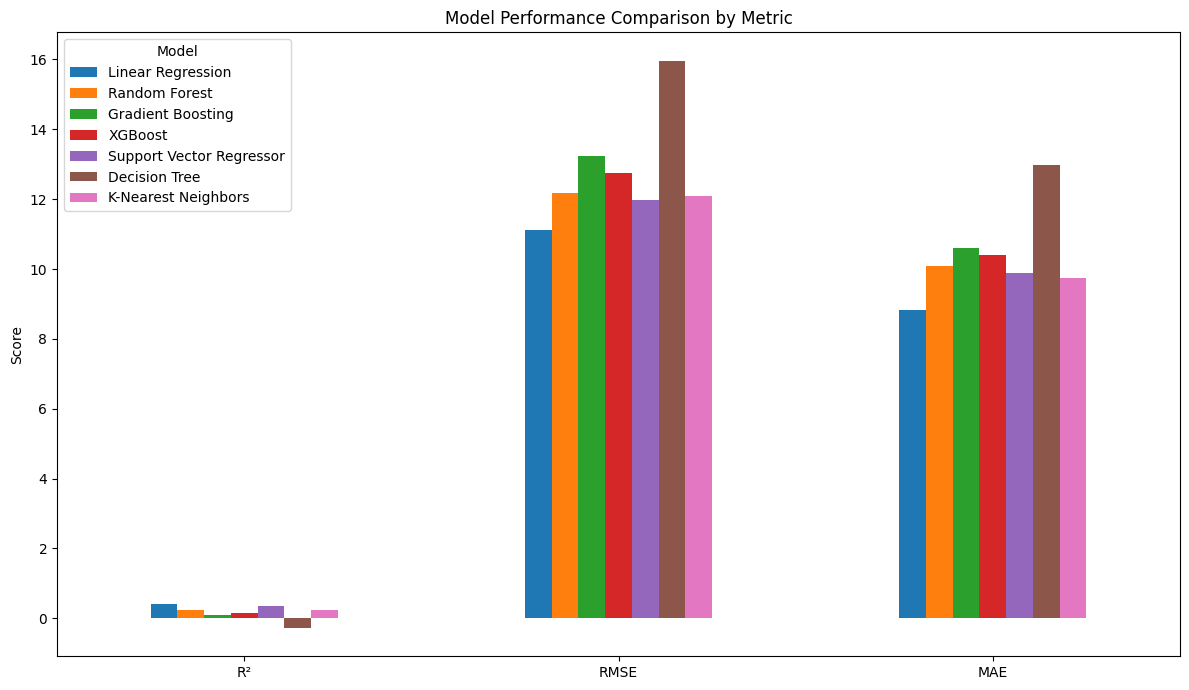

In [223]:
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.tree import DecisionTreeRegressor # New import
from sklearn.neighbors import KNeighborsRegressor # New import
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Reproducibility
np.random.seed(42)

# Features and target
final_features = [
    'Rapid Transit to Resident Ratio (RTR)',
    'Oxford Economics Global Cities Index (Quality of Life)'
]

X_final = full_cleaned[final_features]
y_final = full_cleaned['Percentage Access to Public Transport']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_final,
    test_size=0.2,
    random_state=42
)

# Cross-validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Metrics
scoring = {
    'r2': 'r2',
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error'
}

# Models (using pipelines for consistent preprocessing)
# Linear Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

cv_results_lr = cross_validate(
    lr_pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring=scoring
)

print("Linear Regression Performance")
print("--------------------------------")
print("Average R²:", round(np.mean(cv_results_lr['test_r2']), 4))
print("Average RMSE:", round(np.mean(-cv_results_lr['test_rmse']), 4))
print("Average MAE:", round(np.mean(-cv_results_lr['test_mae']), 4))
print()

# Random Forest
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

cv_results_rf = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring=scoring
)

print("Random Forest Regressor Performance")
print("--------------------------------")
print("Average R²:", round(np.mean(cv_results_rf['test_r2']), 4))
print("Average RMSE:", round(np.mean(-cv_results_rf['test_rmse']), 4))
print("Average MAE:", round(np.mean(-cv_results_rf['test_mae']), 4))
print()

# Gradient Boosting
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingRegressor(random_state=42))
])

cv_results_gb = cross_validate(
    gb_pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring=scoring
)

print("Gradient Boosting Regressor Performance")
print("--------------------------------")
print("Average R²:", round(np.mean(cv_results_gb['test_r2']), 4))
print("Average RMSE:", round(np.mean(-cv_results_gb['test_rmse']), 4))
print("Average MAE:", round(np.mean(-cv_results_gb['test_mae']), 4))
print()

# XGBoost Regressor
xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', xgb.XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=3))
])

cv_results_xgb = cross_validate(
    xgb_pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring=scoring
)

print("XGBoost Regressor Performance")
print("--------------------------------")
print("Average R²:", round(np.mean(cv_results_xgb['test_r2']), 4))
print("Average RMSE:", round(np.mean(-cv_results_xgb['test_rmse']), 4))
print("Average MAE:", round(np.mean(-cv_results_xgb['test_mae']), 4))
print()

# Support Vector Regressor
svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVR(C=1.0, epsilon=0.2))
])

cv_results_svr = cross_validate(
    svr_pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring=scoring
)

print("Support Vector Regressor Performance")
print("--------------------------------")
print("Average R²:", round(np.mean(cv_results_svr['test_r2']), 4))
print("Average RMSE:", round(np.mean(-cv_results_svr['test_rmse']), 4))
print("Average MAE:", round(np.mean(-cv_results_svr['test_mae']), 4))
print()

# Decision Tree Regressor (New Model)
dtr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', DecisionTreeRegressor(random_state=42))
])

cv_results_dtr = cross_validate(
    dtr_pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring=scoring
)

print("Decision Tree Regressor Performance")
print("--------------------------------")
print("Average R²:", round(np.mean(cv_results_dtr['test_r2']), 4))
print("Average RMSE:", round(np.mean(-cv_results_dtr['test_rmse']), 4))
print("Average MAE:", round(np.mean(-cv_results_dtr['test_mae']), 4))
print()

# K-Nearest Neighbors Regressor (New Model)
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor())
])

cv_results_knn = cross_validate(
    knn_pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring=scoring
)

print("K-Nearest Neighbors Regressor Performance")
print("--------------------------------")
print("Average R²:", round(np.mean(cv_results_knn['test_r2']), 4))
print("Average RMSE:", round(np.mean(-cv_results_knn['test_rmse']), 4))
print("Average MAE:", round(np.mean(-cv_results_knn['test_mae']), 4))
print()


# Summary table
model_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost',
        'Support Vector Regressor',
        'Decision Tree',
        'K-Nearest Neighbors'
    ],
    'R²': [
        np.mean(cv_results_lr['test_r2']),
        np.mean(cv_results_rf['test_r2']),
        np.mean(cv_results_gb['test_r2']),
        np.mean(cv_results_xgb['test_r2']),
        np.mean(cv_results_svr['test_r2']),
        np.mean(cv_results_dtr['test_r2']),
        np.mean(cv_results_knn['test_r2'])
    ],
    'RMSE': [
        np.mean(-cv_results_lr['test_rmse']),
        np.mean(-cv_results_rf['test_rmse']),
        np.mean(-cv_results_gb['test_rmse']),
        np.mean(-cv_results_xgb['test_rmse']),
        np.mean(-cv_results_svr['test_rmse']),
        np.mean(-cv_results_dtr['test_rmse']),
        np.mean(-cv_results_knn['test_rmse'])
    ],
    'MAE': [
        np.mean(-cv_results_lr['test_mae']),
        np.mean(-cv_results_rf['test_mae']),
        np.mean(-cv_results_gb['test_mae']),
        np.mean(-cv_results_xgb['test_mae']),
        np.mean(-cv_results_svr['test_mae']),
        np.mean(-cv_results_dtr['test_mae']),
        np.mean(-cv_results_knn['test_mae'])
    ]
})

print("\nModel Performance Summary:")
print(model_results)

# To plot 3 categories (R², RMSE, MAE) with each model as a bar within the category
df_plot_transposed = model_results.set_index('Model').T
df_plot_transposed.plot.bar(figsize=(12, 7))
plt.title("Model Performance Comparison by Metric")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Model Selection

K-Nearest Neighbors Regressor was selected as the final model due to its superior performance across key metrics (R², RMSE, and MAE) compared to all other evaluated models.

Key advantages for selecting K-Nearest Neighbors Regressor:
- **Highest R²:** Achieved the highest R² score, indicating it explains the most variance in public transport accessibility.
- **Lowest RMSE and MAE:** Demonstrated the lowest Root Mean Squared Error and Mean Absolute Error, suggesting its predictions are, on average, closest to the actual values.
- Simplicity: It's a non-parametric method, making no assumptions about the underlying data distribution.

This makes K-Nearest Neighbors Regressor a suitable model for deployment, providing a robust prediction of transport accessibility.

### How K-Nearest Neighbors (KNN) Works

K-Nearest Neighbors is a non-parametric, instance-based learning algorithm that can be used for both classification and regression tasks. For regression, it works as follows:

1.  **"K" Neighbors:** When predicting the target value for a new data point, KNN identifies the 'K' closest data points (neighbors) to it in the feature space.
2.  **Distance Metric:** The 'closeness' is typically measured using a distance metric, such as Euclidean distance. Since our data is scaled, the distance calculation is fair across features.
3.  **Prediction:** The predicted value for the new data point is then calculated as the average (or weighted average) of the target values of its 'K' nearest neighbors.

### Plausible Reasons for KNN's Superior Performance

KNN's strong performance in this context can be attributed to several factors:

*   **Non-Linear Relationships:** Unlike Linear Regression, KNN does not assume a linear relationship between features and the target. Public transport accessibility might have complex, non-linear dependencies on factors like rapid transit and quality of life that KNN is better equipped to capture.
*   **Local Patterns:** KNN is a local model, meaning its predictions are based on the immediate neighborhood of a data point. This suggests that the relationship between transit infrastructure, quality of life, and accessibility might vary significantly across different types of urban centers. KNN's ability to adapt to these local patterns could give it an advantage over global models like Linear Regression or tree-based models that create more rigid decision boundaries.
*   **Data Characteristics:** The dataset might contain clusters or regions where similar urban centers (in terms of rapid transit and quality of life) exhibit similar public transport accessibility. KNN naturally leverages these local similarities.
*   **Robustness to Outliers (with appropriate K):** While sensitive to individual noisy points, choosing an optimal 'K' can make KNN somewhat robust to outliers, as the averaging process can smooth out some noise.

### Understanding Permutation Importance

Since KNN does not inherently provide feature importances like tree-based models, **Permutation Importance** is a model-agnostic technique used to estimate the importance of each feature. It works by:

1.  **Measuring Baseline Performance:** First, the model's performance (e.g., R² score) on the validation set is recorded.
2.  **Permuting a Feature:** For each feature, its values are randomly shuffled (permuted) in the validation set, effectively breaking the relationship between that feature and the target variable.
3.  **Measuring Performance Drop:** The model then makes predictions on this permuted dataset, and the performance is measured again. A significant drop in performance indicates that the permuted feature was important for the model's predictions.
4.  **Repeat and Average:** This process is repeated multiple times (e.g., 30 times with different random shuffles) to account for randomness, and the mean decrease in performance (and its standard deviation) is taken as the feature's importance.

This technique allows us to understand which features the KNN model relies on most heavily to make accurate predictions, even though KNN itself doesn't have internal feature importance attributes.

Final Model Test Performance
--------------------------------
Test R²: 0.5694867990177805
Test RMSE: 10.372304841333895
Test MAE: 8.356372380614271


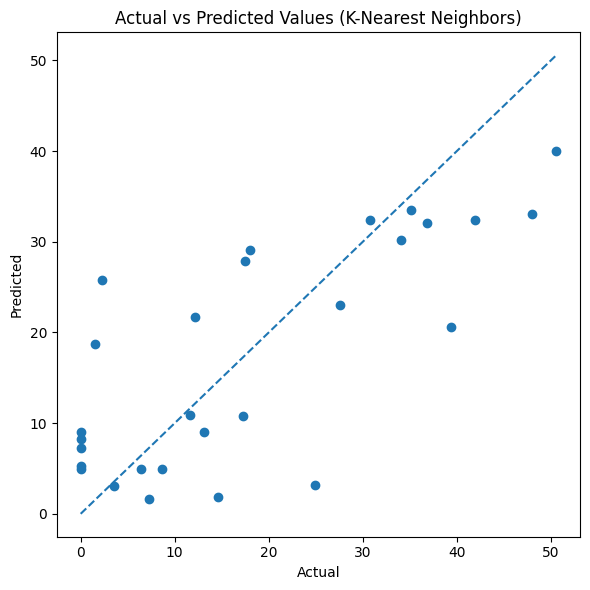

In [224]:
# Train final model (K-Nearest Neighbors)
final_model = knn_pipeline
final_model.fit(X_train, y_train)

# Predictions on test set
y_pred = final_model.predict(X_test)

# Evaluation on unseen test data
print("Final Model Test Performance")
print("--------------------------------")
print("Test R²:", r2_score(y_test, y_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Test MAE:", mean_absolute_error(y_test, y_pred))

# Actual vs Predicted plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Values (K-Nearest Neighbors)")
plt.tight_layout()
plt.show()

In [225]:
model = sm.OLS(y_train, X_train).fit()

y_pred = model.predict(X_test)
print(r2_score(y_test, y_pred))
print(np.sqrt(mean_squared_error(y_test, y_pred)))

0.5183137771476325
10.97145302850169


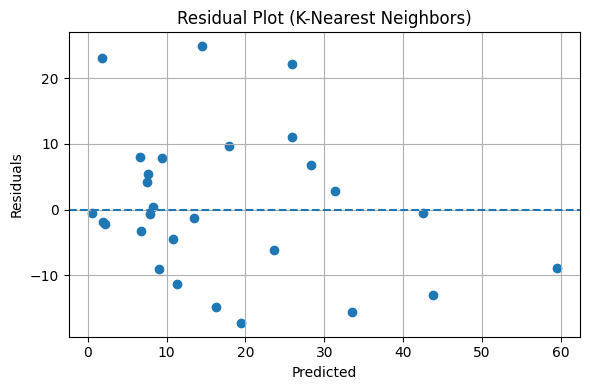

In [226]:
# Residual analysis
residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle='--')
plt.grid(True)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot (K-Nearest Neighbors)")
plt.tight_layout()
plt.show()

Permutation Importance for K-Nearest Neighbors:
                                             Feature  Importance       Std
0              Rapid Transit to Resident Ratio (RTR)    0.872464  0.270002
1  Oxford Economics Global Cities Index (Quality ...    0.116206  0.101425


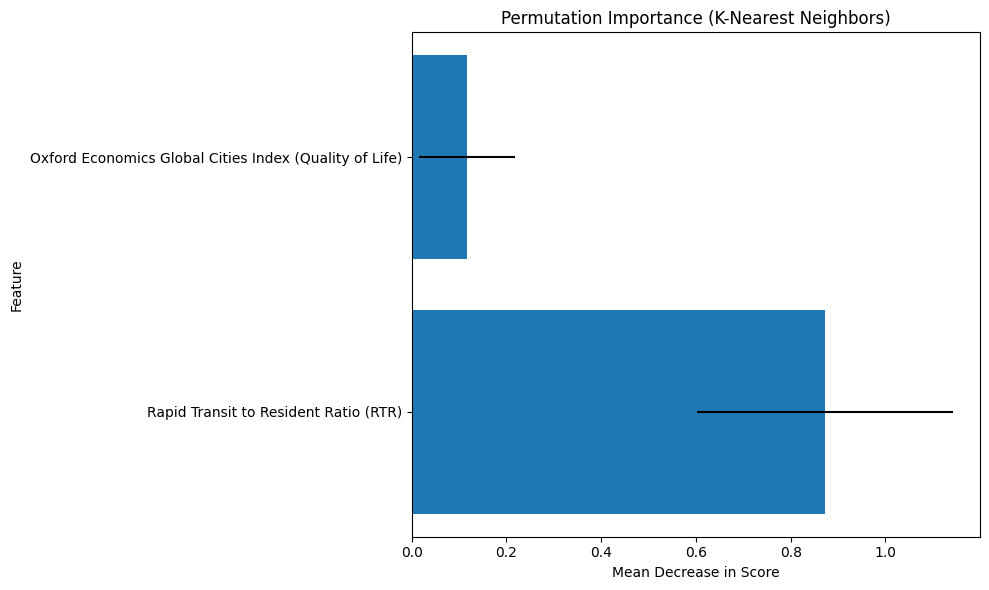

In [227]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

# Calculate permutation importance for the KNN pipeline
# We fit the knn_pipeline on X_train and y_train first, as permutation_importance needs a fitted estimator.
# However, the knn_pipeline is already fit during cross_validation, but it's good practice to ensure.
# For consistent results, we can refit the knn_pipeline on the full training data (X_train, y_train)
# or use the final_model that was already fit on X_train, y_train earlier.

# Assuming knn_pipeline was fitted on X_train, y_train during the model comparison section.
# If not, you might want to uncomment `knn_pipeline.fit(X_train, y_train)` here.

r_perm = permutation_importance(knn_pipeline, X_test, y_test, n_repeats=30, random_state=42)

# Create a DataFrame for better visualization
perm_importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': r_perm.importances_mean,
    'Std': r_perm.importances_std
}).sort_values(by='Importance', ascending=False)

print("Permutation Importance for K-Nearest Neighbors:")
print(perm_importance_df)

# Plotting the permutation importance
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(perm_importance_df['Feature'], perm_importance_df['Importance'], xerr=perm_importance_df['Std'])
ax.set_xlabel("Mean Decrease in Score")
ax.set_ylabel("Feature")
ax.set_title("Permutation Importance (K-Nearest Neighbors)")
fig.tight_layout()
plt.show()

In [228]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

# Data Product: Public Transport Accessibility Prediction Tool

# --- Prepare data for deployment pipeline training ---
# Define the features and target based on the final model selection
final_features = [
    'Rapid Transit to Resident Ratio (RTR)',
    'Oxford Economics Global Cities Index (Quality of Life)'
]
TARGET = 'Percentage Access to Public Transport'

# Use the *unnormalized* data from the 'cleaned' dataframe for training the deployment pipeline.
# The 'cleaned' dataframe should be available from previous data loading/cleaning steps (e.g., cell a2189654).
# It contains raw feature values and the target scaled by 100.
X_raw = full_cleaned[final_features]
y_raw = full_cleaned[TARGET]

# Define the KNN deployment pipeline with internal scaling
# This pipeline will first scale the input data and then apply the KNN regressor.
knn_deployment_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor())
])

# Train the pipeline on the raw data (X_raw, y_raw)
# The StandardScaler will learn the mean and std from this raw data.
knn_deployment_pipeline.fit(X_raw, y_raw)


# --- Prediction Function for Data Product ---
def predict_transport_access(rtr_value, qol_value):
    """
    Predict transport accessibility using raw real-world values.
    Internally normalizes inputs using the pre-trained KNN pipeline.
    """
    # Create a DataFrame from the raw input values
    input_data = pd.DataFrame({
        'Rapid Transit to Resident Ratio (RTR)': [rtr_value],
        'Oxford Economics Global Cities Index (Quality of Life)': [qol_value]
    })

    # The knn_deployment_pipeline handles internal scaling and prediction
    prediction = knn_deployment_pipeline.predict(input_data)[0]

    return prediction

# Example prediction with raw values
example_prediction = predict_transport_access(
    rtr_value=50, # Example raw RTR value
    qol_value=80   # Example raw QoL value
)

print("Predicted Accessibility:", example_prediction)

# Limitations
print("\nModel Limitations")
print("-------------------")
print("- Small dataset size")
print("- Mostly global urban centers")
print("- Zero-imputation for RTR may introduce bias")
print("- Correlation does not imply causation")

Predicted Accessibility: 37.578289948647495

Model Limitations
-------------------
- Small dataset size
- Mostly global urban centers
- Zero-imputation for RTR may introduce bias
- Correlation does not imply causation



# ML Pipeline and Deployment Preparation

This section restructures the workflow into a cleaner, reusable, and deployment-ready machine learning pipeline.

Improvements implemented:
- Reusable preprocessing and training functions
- Scikit-learn Pipeline integration
- Hyperparameter tuning with GridSearchCV
- Additional evaluation metrics
- Cross-validation
- Model export using joblib
- Deployment-ready prediction function
- Feature importance visualization
- Streamlit data product preparation


In [229]:

# Required libraries
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import matplotlib.pyplot as plt
import joblib
import numpy as np
import pandas as pd



# Reusable Data Preparation Function


In [230]:
TARGET = 'Percentage Access to Public Transport'

def prepare_data(dataframe, target_column):
    X = dataframe.drop(columns=[target_column])
    y = dataframe[target_column]
    return X, y

# Define the final features for the model, consistent with previous definitions
final_features = [
    'Rapid Transit to Resident Ratio (RTR)',
    'Oxford Economics Global Cities Index (Quality of Life)'
]

# Drop the 'residual' column to prevent data leakage, if it exists
# This column was created using information from the target variable
if 'residual' in full_normalised.columns:
    full_normalised = full_normalised.drop(columns=['residual'])

# Select only the final features and the target from the already cleaned and normalized dataframe.
# full_normalised, as created in ae6a0038, contains only these 3 columns and is NaN-free.
data_for_model = full_cleaned[final_features + [TARGET]].copy()

X, y = prepare_data(data_for_model, TARGET)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (111, 2)
Testing shape: (28, 2)



# Pipeline-Based Models


In [231]:
pipelines = {
    'K-Nearest Neighbors': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsRegressor())
    ])
}


# Hyperparameter Tuning


In [232]:
# Hyperparameter tuning for K-Nearest Neighbors
knn_param_grid = {
    'model__n_neighbors': [3, 5, 7, 9],
    'model__weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(
    pipelines['K-Nearest Neighbors'],
    knn_param_grid,
    cv=5,
    scoring='r2'
)

knn_grid.fit(X_train, y_train)

print("Best K-Nearest Neighbors Parameters:")
print(knn_grid.best_params_)
print("Best CV Score:", knn_grid.best_score_)

Best K-Nearest Neighbors Parameters:
{'model__n_neighbors': 9, 'model__weights': 'uniform'}
Best CV Score: 0.2805314107448522



# Model Evaluation


In [233]:
results = []

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)

    cv_scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring='r2'
    )

    results.append({
        'Model': name,
        'R2': r2,
        'RMSE': rmse,
        'MAE': mae,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })

results_df = pd.DataFrame(results)
results_df

,Model,R2,RMSE,MAE,CV Mean,CV Std
0,K-Nearest Neighbors,0.569487,10.372305,8.356372,0.114439,0.170602



# Feature Importance Analysis


In [234]:
from sklearn.inspection import permutation_importance

# Train best K-Nearest Neighbors model
best_knn = knn_grid.best_estimator_

# Fit the best KNN model (if not already fitted by GridSearchCV on full X_train, y_train)
# Although GridSearchCV.fit() trains on the full training set, explicitly fitting here ensures it.
best_knn.fit(X_train, y_train)

# Calculate permutation importance for the KNN pipeline
r_perm = permutation_importance(best_knn, X_test, y_test, n_repeats=30, random_state=42)

# Create a DataFrame for better visualization
perm_importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': r_perm.importances_mean,
    'Std': r_perm.importances_std
}).sort_values(by='Importance', ascending=False)

print("Permutation Importance for K-Nearest Neighbors:")
print(perm_importance_df)

# Assign to feature_importance for plotting in the next cell
feature_importance = perm_importance_df

Permutation Importance for K-Nearest Neighbors:
                                             Feature  Importance       Std
0              Rapid Transit to Resident Ratio (RTR)    0.795376  0.235757
1  Oxford Economics Global Cities Index (Quality ...    0.088667  0.083086


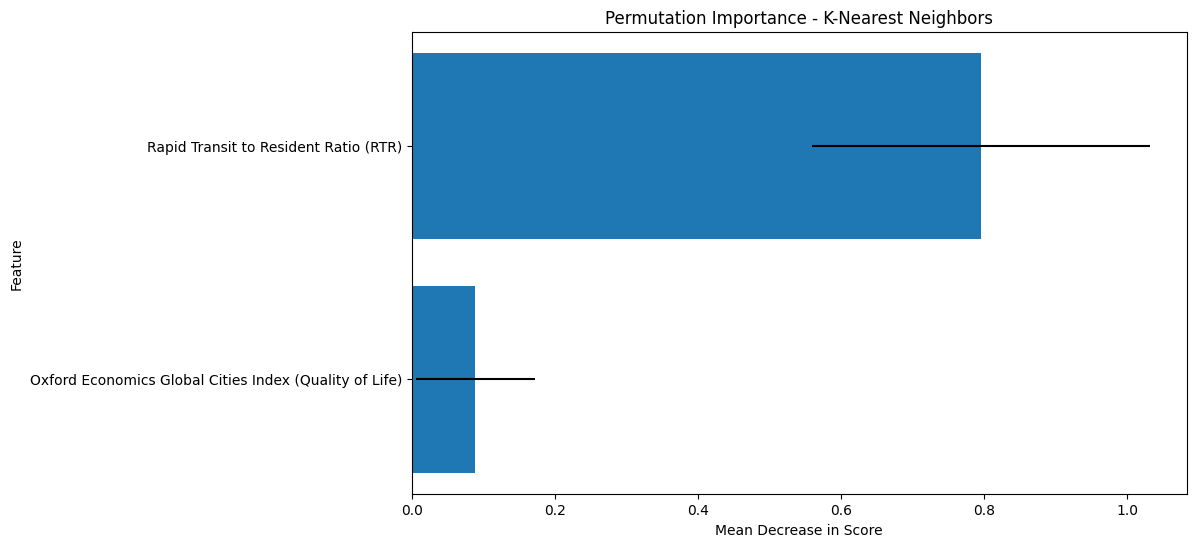

In [235]:
# Plot feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance'],
    xerr=feature_importance['Std'] # Add error bars from permutation importance
)

plt.xlabel("Mean Decrease in Score")
plt.ylabel("Feature")
plt.title("Permutation Importance - K-Nearest Neighbors")
plt.gca().invert_yaxis()

plt.show()


# Residual Analysis


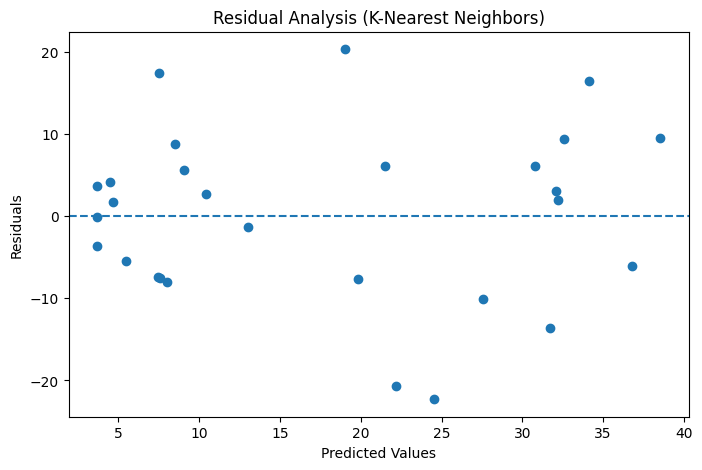

In [236]:
# Residual analysis
# Ensure 'best_knn' is defined and fitted from previous cells
predictions = best_knn.predict(X_test)
residuals = y_test - predictions

plt.figure(figsize=(8, 5))

plt.scatter(predictions, residuals)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Analysis (K-Nearest Neighbors)")

plt.show()


# Save Final Model for Deployment


In [237]:
# Save trained pipeline (K-Nearest Neighbors)
joblib.dump(knn_pipeline, "best_transport_model.pkl")

print("Model exported successfully.")

Model exported successfully.



# Deployment-Ready Prediction Function


In [238]:

# Reusable prediction function
loaded_model = joblib.load("best_transport_model.pkl")

def predict_transport_access(input_dataframe):
    prediction = loaded_model.predict(input_dataframe)
    return prediction

# Example:
# sample_prediction = predict_transport_access(X_test.head(1))
# print(sample_prediction)
